# ch08 연속형 확률변수

- 정규분포

> 전에 배웠던 것들

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate
from scipy.optimize import minimize_scalar

%precision 3
%matplotlib inline

In [39]:
linestyles = ['-', '--', ':']

def E(X, g=lambda x: x):
    x_range, f = X
    def integrand(x):
        return g(x) * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

def V(X, g=lambda x: x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (g(x) - mean) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

def check_prob(X):
    x_range, f = X
    f_min = minimize_scalar(f).fun
    assert f_min >= 0, 'density function is minus value'
    prob_sum = np.round(integrate.quad(f, -np.inf, np.inf)[0], 6)
    assert prob_sum == 1, f'sum of probability is {prob_sum}'
    print(f'expected value {E(X):.3f}')
    print(f'variance {V(X):.3f}')
    
def plot_prob(X, x_min, x_max):
    x_range, f = X
    def F(x):
        return integrate.quad(f, -np.inf, x)[0]

    xs = np.linspace(x_min, x_max, 100)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.plot(xs, [f(x) for x in xs],
            label='f(x)', color='gray')
    ax.plot(xs, [F(x) for x in xs],
            label='F(x)', ls='--', color='gray')

    ax.legend()
    plt.show()

> 표준정규분포: (mu, sigma**2)

In [3]:
def N(mu, sigma):
    x_range = [- np.inf, np.inf]
    def f(x):
        return 1 / np.sqrt(2 * np.pi * sigma**2) *\
                    np.exp(-(x-mu)**2 / (2 * sigma**2))
    return x_range, f

In [4]:
mu, sigma = 2, 0.5
X = N(mu, sigma)

check_prob(X)

expected vaue 2.000
variance 0.250


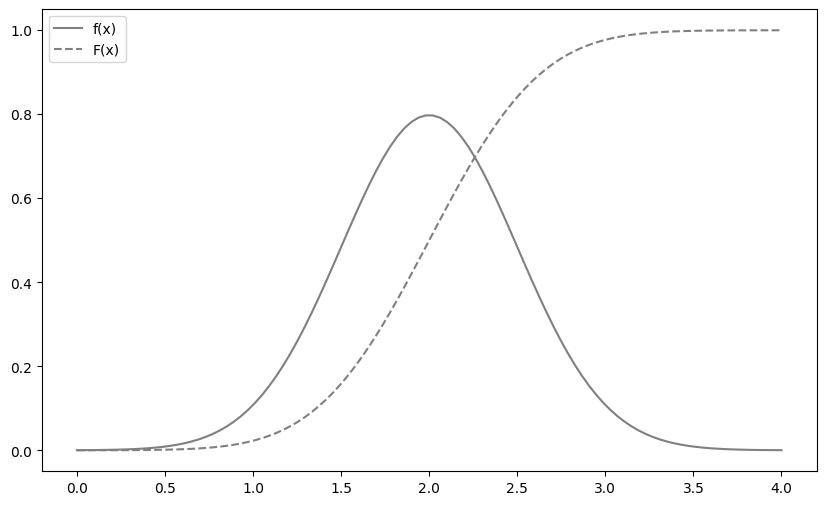

In [5]:
plot_prob(X, 0, 4)

In [6]:
rv = stats.norm(2, 0.5)

rv.mean(), rv.var()

(2.000, 0.250)

In [7]:
rv.pdf(2)

0.798

In [8]:
rv.cdf(1.7)

0.274

In [9]:
rv.isf(0.3)

2.262

In [10]:
rv.interval(0.9)

(1.178, 2.822)

In [11]:
rv.isf(0.95), rv.isf(0.05)

(1.178, 2.822)

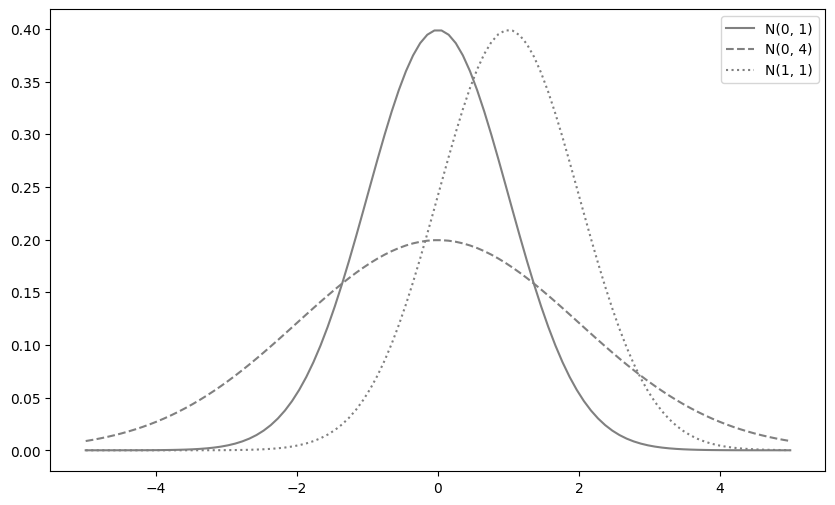

In [12]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(-5, 5, 100)
params = [(0, 1), (0, 2), (1, 1)]
for param, ls in zip(params, linestyles):
    mu, sigma = param
    rv = stats.norm(mu, sigma)
    ax.plot(xs, rv.pdf(xs),
            label=f'N({mu}, {sigma**2})', ls=ls, color='gray')
ax.legend()

plt.show()

### 연습문제

어떤 센서에서 발생한 노이즈는 평균 0, 분산 1인 정규분포를 따른다. 센서는 동일 환경에서 측정 횟수(표본 수)가 많아질수록 데이터 분포 특성이 어떻게 변하는지 알아보자.

> Q1. 표본 수에 따른 분포 비교 시각화
- 표본 수 30, 300, 3000 각 센서 노이즈 데이터를 생성
- 각 표본의 히스토그램
- x축 범위 사용해 세 그래프 비교

> Q2. 이론적 정규분포와의 비교
- 센서 노이즈의 이론적 정규 분포는 N(0,1)
- 표본으로 그린 히스토그램 위에 이론적 정규분포의 확률밀도함수(pdf) 함께 그릴 것
- 표본 수 n이 증가할수록 히스토그램 모양이 이론 pdf와 어떻게 달라지는지 비교

> Q3. 표본 평균과 표본 분산의 수렴 확인
- 각 표본수에 대해 계산된 표본 평균과 표본 분산을 정리

n = 정규분포 >>  0.0 1.0
0.05399096651318806

n = 30 >>  -0.11293255183881487 , 0.9943311944611036
expected value -0.113
variance 0.989

n = 300 >>  0.03396807457508198 , 1.0485273925235385
expected value 0.034
variance 1.099

n = 3000 >>  -0.014578005116691002 , 0.9706770269194807
expected value -0.015
variance 0.942


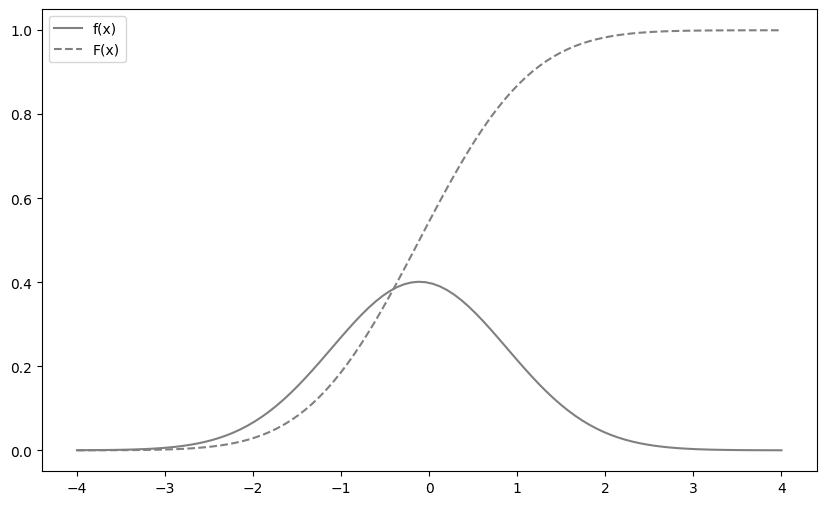

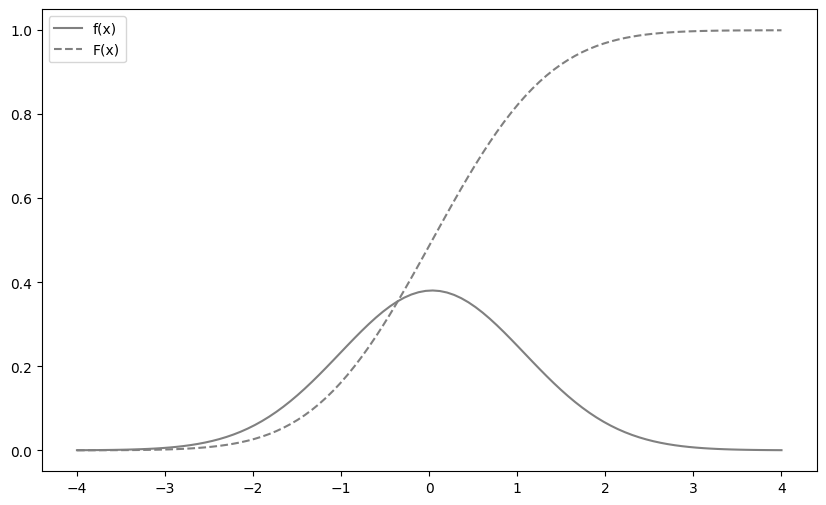

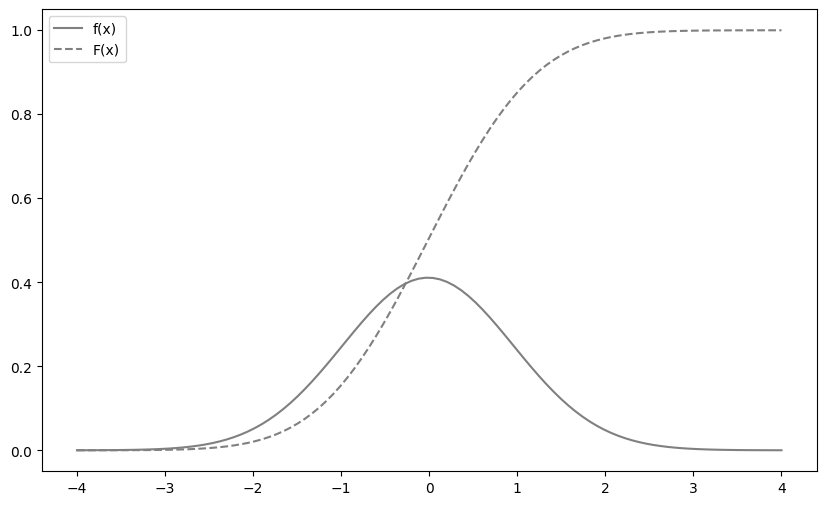

In [63]:
rv = stats.norm(0, 1)
print("n = 정규분포 >> ", rv.mean(), rv.var())
print(rv.pdf(2))
print()

rv30 = rv.rvs(size = 30)
print("n = 30 >> ", rv30.mean(),",", rv30.var())
mu30, sig30 = rv30.mean(), rv30.var()
X30 = N(mu30, sig30)
check_prob(X30)
print()

rv300 = rv.rvs(size = 300)
print("n = 300 >> ", rv300.mean(),",", rv300.var())
mu300, sig300 = rv300.mean(), rv300.var()
X300 = N(mu300, sig300)
check_prob(X300)
print()

rv3000 = rv.rvs(size = 3000)
print("n = 3000 >> ", rv3000.mean(),",", rv3000.var())
mu3000, sig3000 = rv3000.mean(), rv3000.var()
X3000 = N(mu3000, sig3000)
check_prob(X3000)

plot_prob(X30, -4, 4)
plot_prob(X300, -4, 4)
plot_prob(X3000, -4, 4)

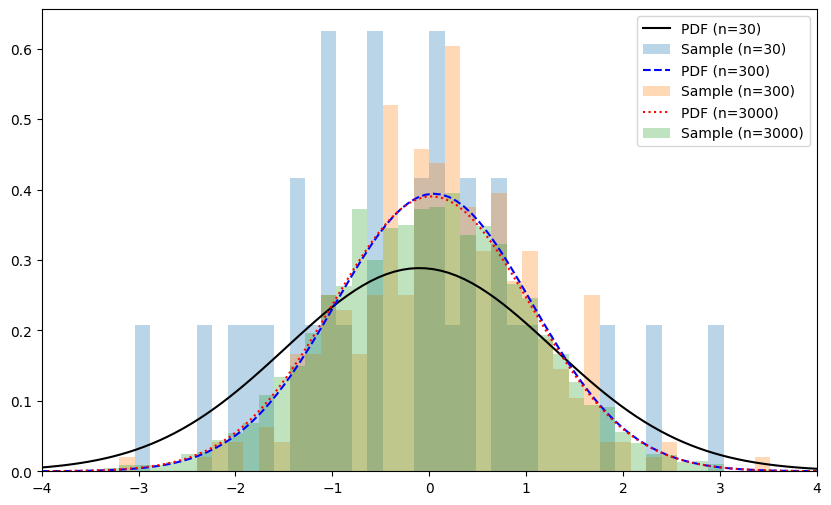

In [48]:
linestyles = ['-', '--', ':']
ns = [30, 300, 3000]
colors = ['black', 'blue', 'red']
x_min, x_max = -4, 4

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(x_min, x_max, 100)

params = [(mu30, sig30), (mu300, sig300), (mu3000, sig3000)] 

for param, n, ls, c in zip(params, ns, linestyles, colors):
    mu, sigma = param
    rv = stats.norm(mu, sigma)
    data = rv.rvs(size=n)

    ax.plot(xs, rv.pdf(xs), label=f'PDF (n={n})', ls=ls, color = c)
    ax.hist(data, bins=50, range=(x_min, x_max), 
            density=True, alpha=0.3, label=f'Sample (n={n})')
    
ax.set_xlim(x_min, x_max)
ax.legend()

plt.show()

In [ ]:
import pandas as pd
data = [
    [30, mu30, sig30 ],
    [300, mu300, sig300],
    [3000, mu3000, sig3000]
]
df = pd.DataFrame(data,columns = ['표본 수(n)', '표본 평균', '표본 분산'])
df

,표본 수(n),표본 평균,표본 분산
0,30,-0.112933,0.994331
1,300,0.033968,1.048527
2,3000,-0.014578,0.970677


- 지수분포

In [68]:
def Ex(lam):
    x_range = [0, np.inf]
    def f(x):
        if x >= 0:
            return lam * np.exp(-lam * x)
        else:
            return 0
    return x_range, f

In [69]:
lam = 3
X = Ex(lam)

check_prob(X)

expected value 0.333
variance 0.111


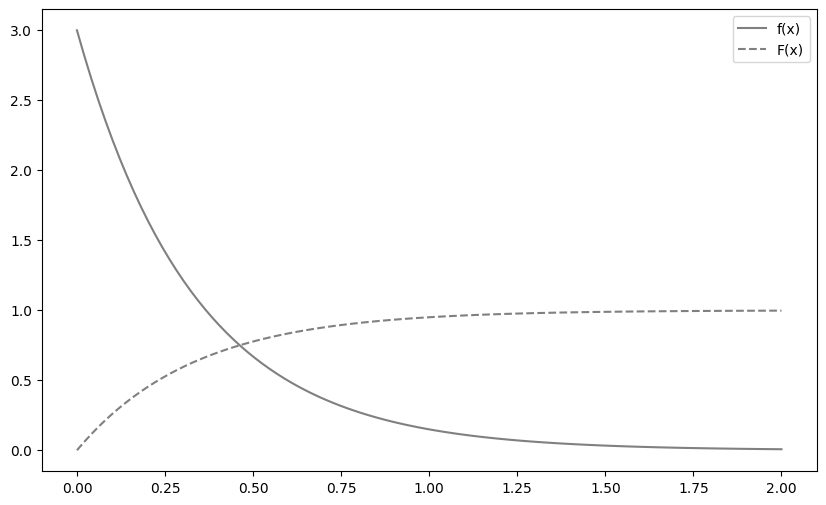

In [70]:
plot_prob(X, 0, 2)

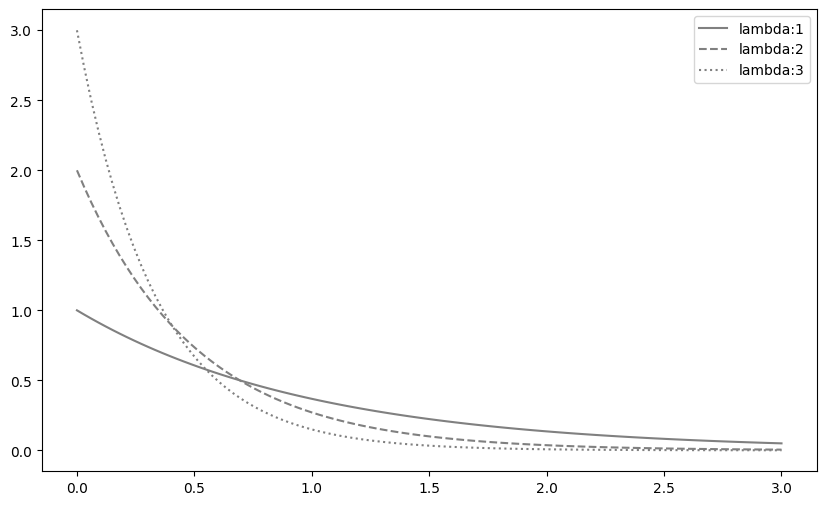

In [71]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(0, 3, 100)
for lam, ls in zip([1, 2, 3], linestyles):
    rv = stats.expon(scale=1/lam)
    ax.plot(xs, rv.pdf(xs),
            label=f'lambda:{lam}', ls=ls, color='gray')
ax.legend()

plt.show()

### 연습문제

어떤 기계의 고장까지 걸리는 시간 X는 X~Ex(lambda = 0.5)를 따른다. 기계는 이미 2시간동안 정상 작동중이다

> Q1. 앞으로 1시간 이내에 고장 발생할 확률 P(X <= 3 | X > 2) 이론 계산. 위 확률이 P(X <= 1)과 같은가? 같다면, 그 이유를 지수분포의 성질을 이용해 설명

> Q2. 지수분포 Ex(lambda = 0.5)로부터 충분히 큰 표본(예> 10만 개 이상)을 생성. 전체 표본 중 X > 2인 데이터만 추출, 그 중 X <= 3인 비율을 계산해 P(X <= 3 | X > 2)를 표본 기반 확률로 구할 것

> Q3. X~Ex(0.5)의 이론적 확률밀도함수(pdf) 그리고, x = 2 지점에 수직선 추가. 조건부확률 P(X <= 3 | X > 2)에 해당하는 구간 시각화해 강조. 같은 그래프 또는 별도의 그래프에서 P(X <= 1)에 해당하는 영역 비교

In [89]:
lam = 0.5
rv = stats.expon(scale = 1/lam)

#P(2 < X <= 3)
one = rv.cdf(3) - rv.cdf(2)

#P(X > 2)
two = rv.sf(2)

tot = one / two

#P(X <= 1)
three = rv.cdf(1)

print(f"1. 이론적 P(X <= 3 | X > 2) 계산 결과: {tot:.4f}")
print(f"2. 이론적 P(X <= 1) 계산 결과       : {three:.4f}")
print(f"3. 두 값이 같은가?                   : {np.isclose(tot, three)}")

1. 이론적 P(X <= 3 | X > 2) 계산 결과: 0.3935
2. 이론적 P(X <= 1) 계산 결과       : 0.3935
3. 두 값이 같은가?                   : True


In [ ]:
def Ex(lam):
    x_range = [0, np.inf]
    def f(x):
        if x >= 0:
            return lam * np.exp(-lam * x)
        else:
            return 0
    return x_range, f

samples = stats.expon.rvs(scale=1/lam, size=100000)

q2 = samples[samples > 2]
p = np.sum(q2 <= 3) / len(q2)

X = Ex(lam)
check_prob(X)

expected value 2.000
variance 4.000


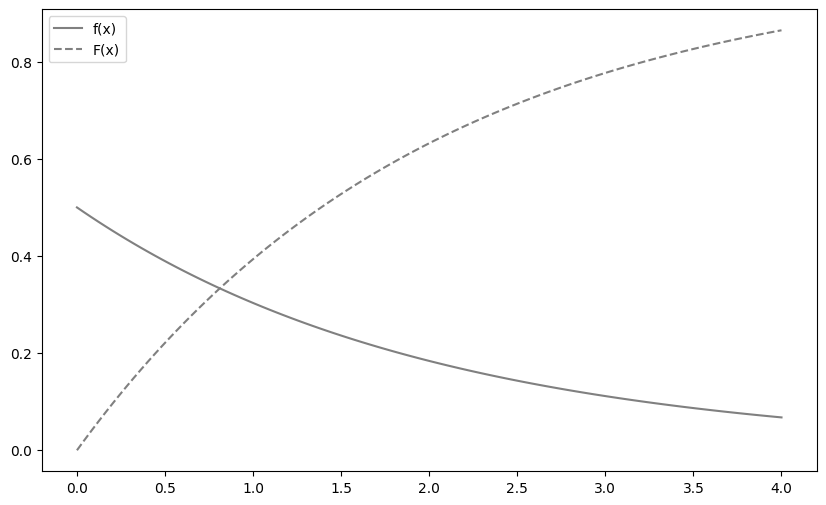

In [83]:
plot_prob(X, 0, 4)

In [86]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

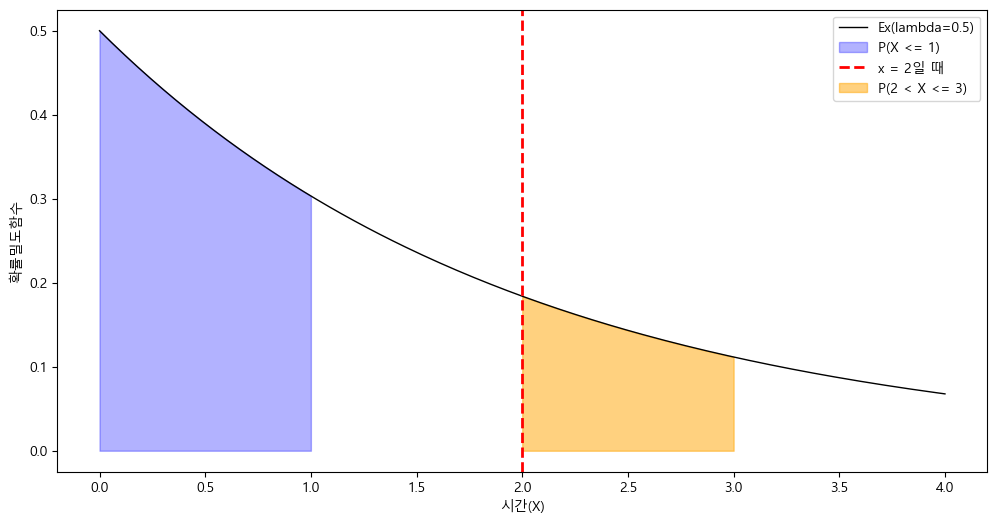

In [91]:
xs = np.linspace(0, 4, 200)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# 1. 이론적 확률밀도함수(pdf)
ax.plot(xs, rv.pdf(xs), label=f'Ex(lambda=0.5)', color='black', lw=1)

# 2. P(X <= 1)
xs_1 = np.linspace(0, 1, 50)
ax.fill_between(xs_1, rv.pdf(xs_1), alpha=0.3, color='blue', label='P(X <= 1)')

# 3. x = 2 지점에 수직선
ax.axvline(2, color='red', ls='--', lw=2, label='x = 2일 때')

# 4. P(X <= 3 | X > 2)
xs_23 = np.linspace(2, 3, 50)
ax.fill_between(xs_23, rv.pdf(xs_23), alpha=0.5, color='orange', label='P(2 < X <= 3)')

ax.set_xlabel('시간(X)')
ax.set_ylabel('확률밀도함수')
ax.legend()

plt.show()

- 카이제곱분포

In [92]:
n = 10
rv = stats.norm()
sample_size = int(1e6)
# 표준정규분포로부터 10×100만 사이즈로 무작위추출
Zs_sample = rv.rvs((n, sample_size))
# axis=0에서 총합을 구하고, 표준정규분포의 제곱합 표본 데이터를 구한다
chi2_sample = np.sum(Zs_sample**2, axis=0)

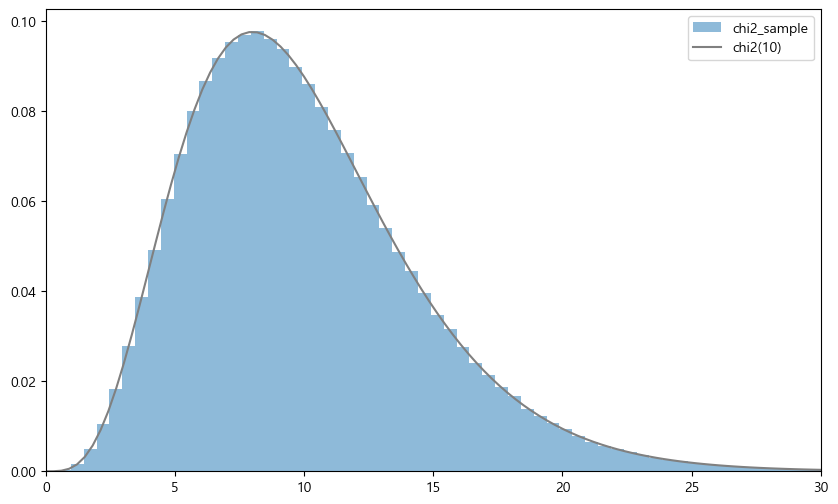

In [93]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv_true = stats.chi2(n)
xs = np.linspace(0, 30, 100)
ax.hist(chi2_sample, bins=100, density=True,
        alpha=0.5, label='chi2_sample')
ax.plot(xs, rv_true.pdf(xs), label=f'chi2({n})', color='gray')

ax.legend()
ax.set_xlim(0, 30)
plt.show()

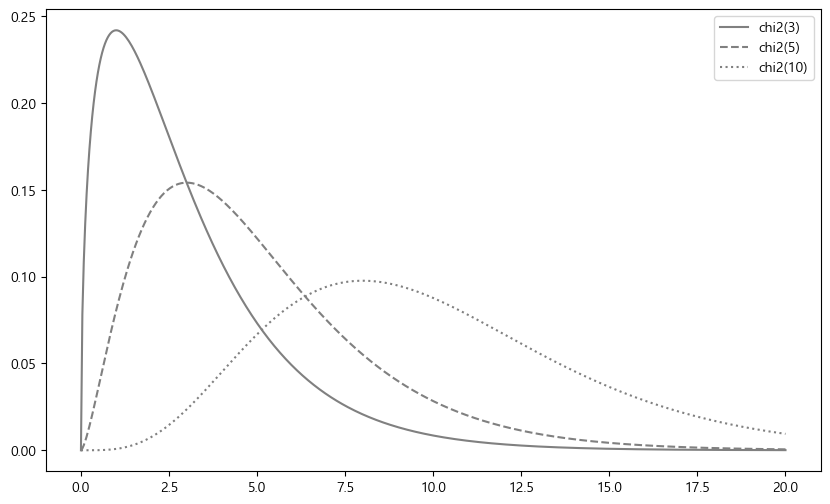

In [94]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(0, 20, 500)
for n, ls in zip([3, 5, 10], linestyles):
    rv = stats.chi2(n)
    ax.plot(xs, rv.pdf(xs),
            label=f'chi2({n})', ls=ls, color='gray')
    
ax.legend()
plt.show()

In [95]:
rv = stats.chi2(5)
rv.isf(0.05)

11.070

### 연습문제

서로 독립인 확률변수 Z1, Z2, Z3 ~ N(0,1)라 하자. Y = Z1**2 + Z2**2 + Z3**2

> 생성
- 표준정규분포로 N(0,1) 표본 수 10만 개 생성

> 카이제곱 변수 만들기
- 생성한 표준정규 표본을 이용해 Y = Z1**2 + Z2**2 + Z3**2 계산

> 분포 시각화
- Y의 히스토그램 그리기
- 자유도 3인 카이제곱분포의 이론적 확률밀도함수(pdf)를 히스토그램 위에 그리시오.
히스토그램과 이론적 분포가 비슷하게 나타나는지 확인

In [107]:
sample_size = 100000
z1 = np.random.normal(0, 1, sample_size)
z2 = np.random.normal(0, 1, sample_size)
z3 = np.random.normal(0, 1, sample_size)

y = z1**2 + z2**2 + z3**2

In [108]:
n = 10
rv = stats.norm()
sample_size = int(1e5)
# 표준정규분포로부터 10×100만 사이즈로 무작위추출
Zs_sample = rv.rvs((n, sample_size))
# axis=0에서 총합을 구하고, 표준정규분포의 제곱합 표본 데이터를 구한다
chi2_sample = np.sum(Zs_sample**2, axis=0)

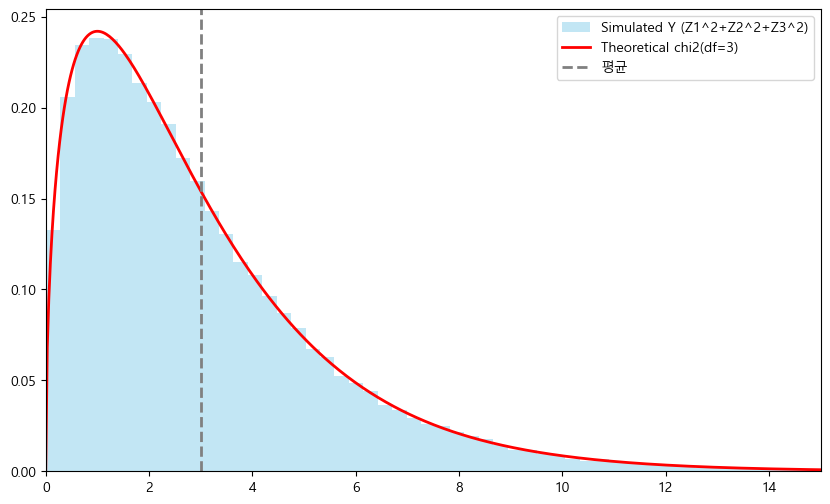

In [114]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(y, bins=100, density=True, alpha=0.5, label='Simulated Y (Z1^2+Z2^2+Z3^2)', color='skyblue')
xs = np.linspace(0, 15, 500)
rv_chi3 = stats.chi2(df=3)
ax.plot(xs, rv_chi3.pdf(xs), label='Theoretical chi2(df=3)', color='red', lw=2)
ax.axvline(y.mean(), color='gray', ls='--', lw=2, label='평균')

ax.legend()
ax.set_xlim(0, 15)
plt.show()

- t 분포

- F 분포